In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import seaborn as sns
import casadi as ca

## Parámetros del sistema y configuración de simulación

In [ ]:
# Áreas de la sección transversal de los tanques [cm^2]
A1, A3 = 28.0, 28.0
A2, A4 = 32.0, 32.0

# Áreas de los orificios de salida [cm^2]
a1, a3 = 0.071, 0.071
a2, a4 = 0.057, 0.057

# Constantes de flujo de las bombas [cm^3/Vs]
k1, k2 = 3.33, 3.35

# Parámetros de división de flujo entre tanques superiores e inferiores
gamma1, gamma2 = 0.70, 0.60

# Aceleración de la gravedad constante [cm/s^2]
g = 981.0

# Configuración del tiempo y paso de integración
dt = 0.05
T_sim = 5000
t = np.arange(0, T_sim + dt, dt)
n = len(t)

# Condiciones iniciales para los niveles de los cuatro tanques [cm]
h0 = np.array([12.4, 12.7, 1.8, 1.4])

# Desviación estándar del ruido gaussiano para entradas y salidas
noise_input_std = 0.1
noise_output_std = 0.1

# Duración de los escalones para la señal de excitación
t_cambio_min = 50
t_cambio_max = 50

# Límites de operación de voltaje para las bombas de agua
V_min = 0.0
V_max = 6.0

## Función del sistema dinámico no lineal de cuatro tanques

El sistema se describe mediante el siguiente conjunto de ecuaciones acopladas:

$$\frac{dh_1}{dt} = -\frac{a_1}{A_1} \sqrt{2gh_1} + \frac{a_3}{A_1} \sqrt{2gh_3} + \frac{\gamma_1 k_1}{A_1} v_1$$
$$\frac{dh_2}{dt} = -\frac{a_2}{A_2} \sqrt{2gh_2} + \frac{a_4}{A_2} \sqrt{2gh_4} + \frac{\gamma_2 k_2}{A_2} v_2$$
$$\frac{dh_3}{dt} = -\frac{a_3}{A_3} \sqrt{2gh_3} + \frac{(1 - \gamma_2) k_2}{A_3} v_2$$
$$\frac{dh_4}{dt} = -\frac{a_4}{A_4} \sqrt{2gh_4} + \frac{(1 - \gamma_1) k_1}{A_4} v_1$$


In [ ]:
def nonlinear_ode_system_model(t, h, u_func, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2):
    # Desempaquetado de niveles de los cuatro tanques
    h1, h2, h3, h4 = h
    eps = 1e-6

    # Protección numérica para evitar raíces cuadradas de valores negativos
    h_seguro = np.maximum(h, eps)
    h1_s, h2_s, h3_s, h4_s = h_seguro

    # Obtención de voltajes de entrada en el tiempo t
    v1, v2 = u_func(t)

    # Balance de masa para tanques inferiores con aporte de tanques superiores
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h1_s) + (a3 / A1) * np.sqrt(2 * g * h3_s) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h2_s) + (a4 / A2) * np.sqrt(2 * g * h4_s) + (gamma2 * k2 / A2) * v2

    # Balance de masa para tanques superiores alimentados por flujo dividido
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h3_s) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h4_s) + ((1 - gamma1) * k1 / A4) * v1

    # Retorno de las derivadas de estado para el integrador
    return [dh1dt, dh2dt, dh3dt, dh4dt]

## Creación de señales PBRS de entrada

In [ ]:
# Configuración del generador de números aleatorios con semilla fija
seed_stream = 100
rng_stream = np.random.Generator(np.random.MT19937(seed_stream))

# Inicialización de índices para los cambios de nivel en la señal
t_cambio_indices = []
curr_idx = 0

# Generación de intervalos de duración aleatoria para los escalones
while curr_idx < n:
    t_cambio_indices.append(curr_idx)

    # Cálculo de la duración del escalón en segundos y su equivalente en pasos
    duracion_seg = rng_stream.uniform(t_cambio_min, t_cambio_max)
    pasos_escalon = int(duracion_seg / dt)
    curr_idx += pasos_escalon

# Generación de amplitudes aleatorias para los voltajes de ambas bombas
valores_escalones = rng_stream.uniform(V_min, V_max, size=(len(t_cambio_indices), 2))

## Construcción de la señal de entrada y adición de ruido

La señal de entrada final se modela como:
$$u_{real}(t) = \text{sat}_{V_{min}}^{V_{max}} \{ u_{ideal}(t) + \eta_u(t) \}$$

In [ ]:
# Inicialización de la matriz para la señal de entrada sin perturbaciones
u_ideal = np.zeros((n, 2))

# Construcción de la señal constante a trozos basada en los índices de cambio
for i in range(len(t_cambio_indices)):
    idx_start = t_cambio_indices[i]

    # Definición del límite superior del intervalo actual
    if i == len(t_cambio_indices) - 1:
        idx_end = n
    else:
        idx_end = t_cambio_indices[i+1]

    # Asignación de voltajes v1 y v2 para el segmento de tiempo definido
    u_ideal[idx_start:idx_end, :] = valores_escalones[i]

# Generación de ruido blanco gaussiano para simular incertidumbre en actuadores
ruido_input = noise_input_std * rng_stream.standard_normal(size=u_ideal.shape)

# Aplicación de ruido y restricción de la señal a los límites físicos de operación
u_ruidosa = u_ideal + ruido_input
u_ruidosa = np.clip(u_ruidosa, V_min, V_max)

## Simulación del sistema mediante integración numérica

In [ ]:
# Creación de función de interpolación para la entrada ruidosa
u_fun = interp1d(t, u_ruidosa, axis=0, kind='linear', fill_value='extrapolate')

# Definición del wrapper para integrar el modelo con parámetros fijos
ode_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_fun,
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2, gamma1, gamma2
)

# Resolución del sistema de ecuaciones diferenciales mediante RK45
sol = solve_ivp(
    fun=ode_wrapper,
    t_span=[t[0], t[-1]],
    y0=h0,
    method='RK45',
    t_eval=t,
    rtol=1e-6,
    atol=1e-8
)

# Extracción y organización de las trayectorias de nivel simuladas
h_out = sol.y.T
h1_sim, h2_sim, h3_sim, h4_sim = h_out[:, 0], h_out[:, 1], h_out[:, 2], h_out[:, 3]
t_out = sol.t

## Adicción de ruido gaussiano a la simulación del sistema

In [ ]:
# Generación de ruido blanco gaussiano para los sensores de los cuatro tanques
ruido_h1 = noise_output_std * rng_stream.standard_normal(size=h1_sim.shape)
ruido_h2 = noise_output_std * rng_stream.standard_normal(size=h2_sim.shape)
ruido_h3 = noise_output_std * rng_stream.standard_normal(size=h3_sim.shape)
ruido_h4 = noise_output_std * rng_stream.standard_normal(size=h4_sim.shape)

# Aplicación de ruido a niveles simulados con restricción de límite físico inferior
h1_ruidosa = np.maximum(h1_sim + ruido_h1, 0.0)
h2_ruidosa = np.maximum(h2_sim + ruido_h2, 0.0)
h3_ruidosa = np.maximum(h3_sim + ruido_h3, 0.0)
h4_ruidosa = np.maximum(h4_sim + ruido_h4, 0.0)

# Consolidación de vectores temporales, entradas ruidosas y niveles medidos
t_full = t_out
u_full = u_ruidosa
h1_full = h1_ruidosa
h2_full = h2_ruidosa
h3_full = h3_ruidosa
h4_full = h4_ruidosa

# Definición de la dimensión total del conjunto de datos de entrenamiento
N_TOTAL = t_full.shape[0]

## Visualización de simulación del sistema de cuatro tanques

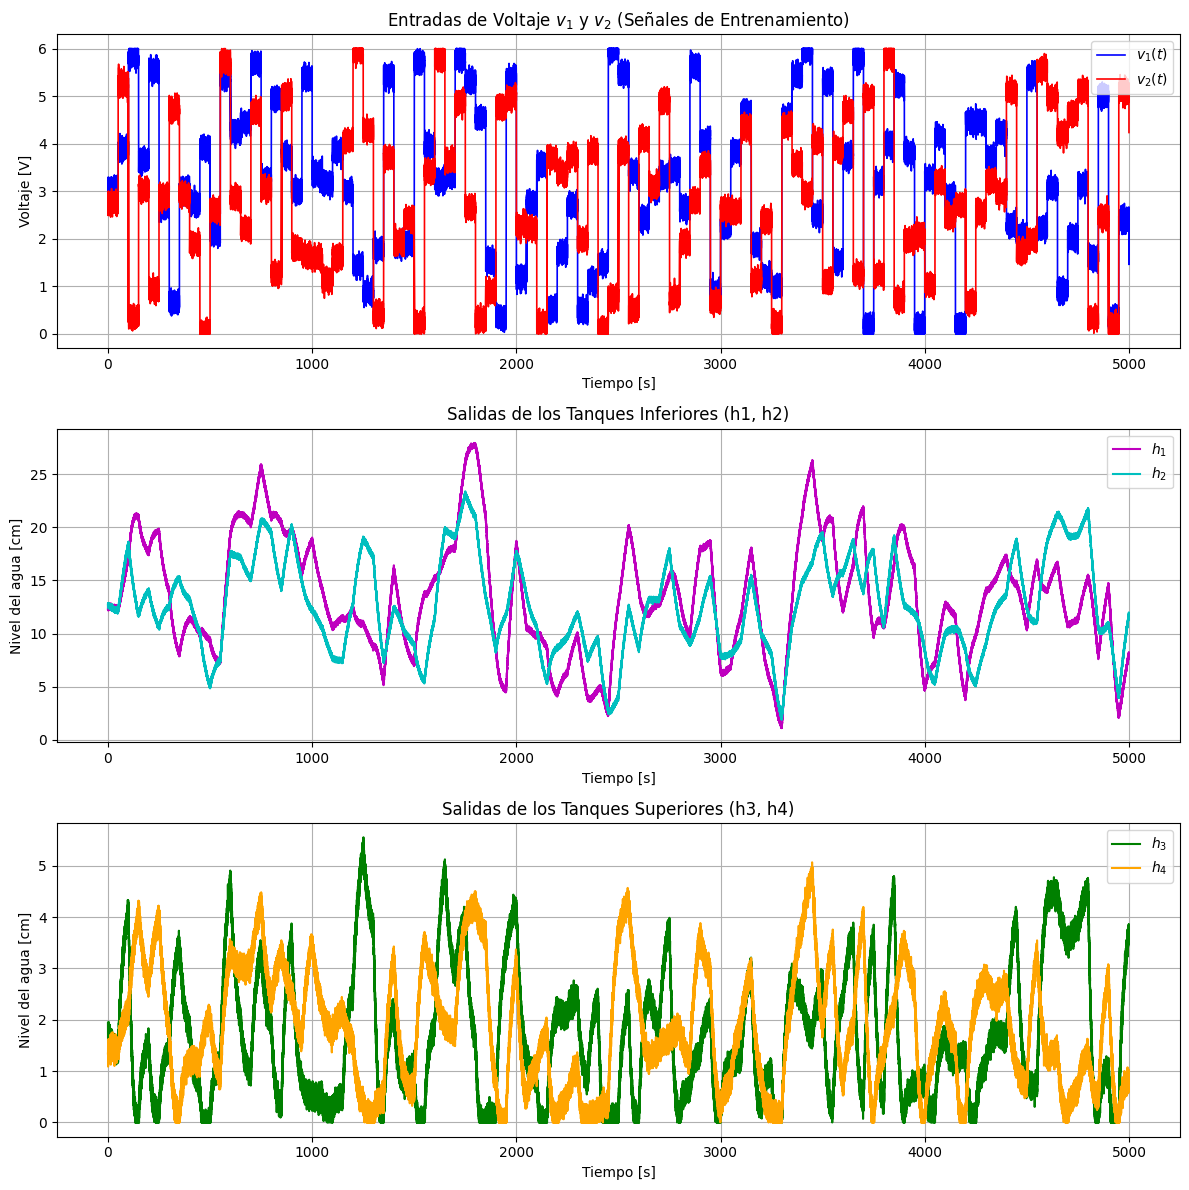

In [ ]:
# Creación del lienzo para la visualización de señales de entrenamiento
plt.figure(figsize=(12, 12))

# Visualización de los voltajes de entrada aplicados a las bombas
plt.subplot(3, 1, 1)
plt.plot(t_full, u_full[:, 0], 'b', linewidth=1.2, label='$v_1(t)$')
plt.plot(t_full, u_full[:, 1], 'r', linewidth=1.2, label='$v_2(t)$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [V]')
plt.title('Entradas de Voltaje $v_1$ y $v_2$ (Señales de Entrenamiento)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualización de la respuesta dinámica de los tanques inferiores
plt.subplot(3, 1, 2)
plt.plot(t_full, h1_full, 'm', linewidth=1.5, label='$h_1$')
plt.plot(t_full, h2_full, 'c', linewidth=1.5, label='$h_2$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel del agua [cm]')
plt.title('Salidas de los Tanques Inferiores (h1, h2)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualización de la respuesta dinámica de los tanques superiores
plt.subplot(3, 1, 3)
plt.plot(t_full, h3_full, 'g', linewidth=1.5, label='$h_3$')
plt.plot(t_full, h4_full, 'orange', linewidth=1.5, label='$h_4$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel del agua [cm]')
plt.title('Salidas de los Tanques Superiores (h3, h4)')
plt.legend(loc='upper right')
plt.grid(True)

# Ajuste de disposición y despliegue de las subgráficas
plt.tight_layout()
plt.show()

In [ ]:
def kalman_filter(z, Q=1e-5, R=1e-2):
    n = len(z)
    x_hat = np.zeros(n)      # Estimación del nivel
    P = np.zeros(n)          # Covarianza del error
    x_hat[0] = z[0]
    P[0] = 1.0

    for k in range(1, n):
        # Predicción
        x_hat_minus = x_hat[k-1]
        P_minus = P[k-1] + Q
        # Actualización
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (z[k] - x_hat_minus)
        P[k] = (1 - K) * P_minus
    return x_hat

# Aplicación con parámetros de sintonía (Q: proceso, R: sensor)
h1_full = kalman_filter(h1_full)
h2_full = kalman_filter(h2_full)
h3_full = kalman_filter(h3_full)
h4_full = kalman_filter(h4_full)
u_full[:,0] = kalman_filter(u_full[:,0])
u_full[:,1] = kalman_filter(u_full[:,1])

In [ ]:
# 1. Preparación de datos (Usando h_full que tiene el ruido de medición)
def lift_func(h_data):
    h_safe = np.maximum(h_data, 1e-6) # Protección contra valores negativos en raíz
    return np.hstack([
        h_data,
        np.sqrt(h_safe),
        np.sin(h_data),
        np.cos(h_data),
        h_data ** 2
    ])

h_ruidoso_stacked = np.column_stack([h1_full, h2_full, h3_full, h4_full])
Z = lift_func(h_out)
Z_curr = Z[:-1]
Z_next = Z[1:]
U_curr = u_full[:-1]

# 2. Construcción de la matriz de regresión bilineal
X_reg = np.hstack([
    Z_curr,
    Z_curr * U_curr[:, 0:1],
    Z_curr * U_curr[:, 1:2],
    U_curr
])

# 3. Identificación del operador (Matrices A, B1, B2, D)
model_koopman = Ridge(alpha=1e-2, fit_intercept=False)
model_koopman.fit(X_reg, Z_next)
W = model_koopman.coef_

nz = Z_curr.shape[1]
A_k = W[:, :nz]
B1_k = W[:, nz:2*nz]
B2_k = W[:, 2*nz:3*nz]
D_k = W[:, 3*nz:] # Término de control puramente aditivo

# --- NUEVA SECCIÓN: ENTRENAMIENTO DE LA MATRIZ DE SALIDA C ---
# Queremos encontrar C tal que h_fisico = C @ z
# Se entrena usando todos los datos disponibles (Z) contra los niveles reales (h_ruidoso)
model_output = Ridge(alpha=10, fit_intercept=False)
model_output.fit(Z, h_out)
C_matrix = model_output.coef_  # Esta es tu matriz de salida (dimensión 4 x nz)

# 4. Simulación recursiva
n_steps = len(u_full)
z_sim = np.zeros((n_steps, nz))
z_sim[0] = Z[0]

for k in range(n_steps - 1):
    u = u_full[k]
    # Evolución en el espacio latente (levantado)
    z_next = A_k @ z_sim[k] + (B1_k @ z_sim[k])*u[0] + (B2_k @ z_sim[k])*u[1] + D_k @ u

    # Clip de seguridad opcional para evitar explosión numérica
    z_sim[k+1] = z_next

# 5. Proyección al espacio original usando la Matriz de Salida C
# En lugar de h_koopman = z_sim[:, :4], usamos la matriz entrenada:
h_koopman = (C_matrix @ z_sim.T).T

In [ ]:
def calculate_metrics(real, pred):
    # Root Mean Square Error (RMSE): Magnitud del error cuadrático en cm
    rmse = np.sqrt(np.mean((real - pred)**2))

    # Mean Absolute Error (MAE): Promedio de los errores absolutos en cm
    mae = np.mean(np.abs(real - pred))

    # Variance Actually Fraction (VAF): Calidad de la captura de la dinámica (%)
    # Un VAF de 100% indica una predicción perfecta de la varianza del sistema.
    vaf = max(0, (1 - np.var(real - pred) / np.var(real)) * 100)

    return rmse, mae, vaf

# Cálculo de métricas para la fase de Identificación Koopman (los 4 tanques)
rmse1, mae1, vaf1 = calculate_metrics(h_out[:, 0], h_koopman[:, 0])
rmse2, mae2, vaf2 = calculate_metrics(h_out[:, 1], h_koopman[:, 1])
rmse3, mae3, vaf3 = calculate_metrics(h_out[:, 2], h_koopman[:, 2])
rmse4, mae4, vaf4 = calculate_metrics(h_out[:, 3], h_koopman[:, 3])

# --- REPORTE DE RESULTADOS EN CONSOLA ---
print("\n" + "="*60)
print(f"{'TANQUE':<12} | {'RMSE [cm]':<12} | {'MAE [cm]':<12} | {'VAF [%]':<10}")
print("-" * 60)
print(f"{'Tanque 1 (h1)':<12} | {rmse1:9.4f}    | {mae1:9.4f}    | {vaf1:7.2f}%")
print(f"{'Tanque 2 (h2)':<12} | {rmse2:9.4f}    | {mae2:9.4f}    | {vaf2:7.2f}%")
print(f"{'Tanque 3 (h3)':<12} | {rmse3:9.4f}    | {mae3:9.4f}    | {vaf3:7.2f}%")
print(f"{'Tanque 4 (h4)':<12} | {rmse4:9.4f}    | {mae4:9.4f}    | {vaf4:7.2f}%")
print("="*60 + "\n")


TANQUE       | RMSE [cm]    | MAE [cm]     | VAF [%]   
------------------------------------------------------------
Tanque 1 (h1) |    0.1719    |    0.1383    |   99.90%
Tanque 2 (h2) |    0.1585    |    0.1225    |   99.87%
Tanque 3 (h3) |    0.0610    |    0.0458    |   99.77%
Tanque 4 (h4) |    0.0396    |    0.0310    |   99.88%



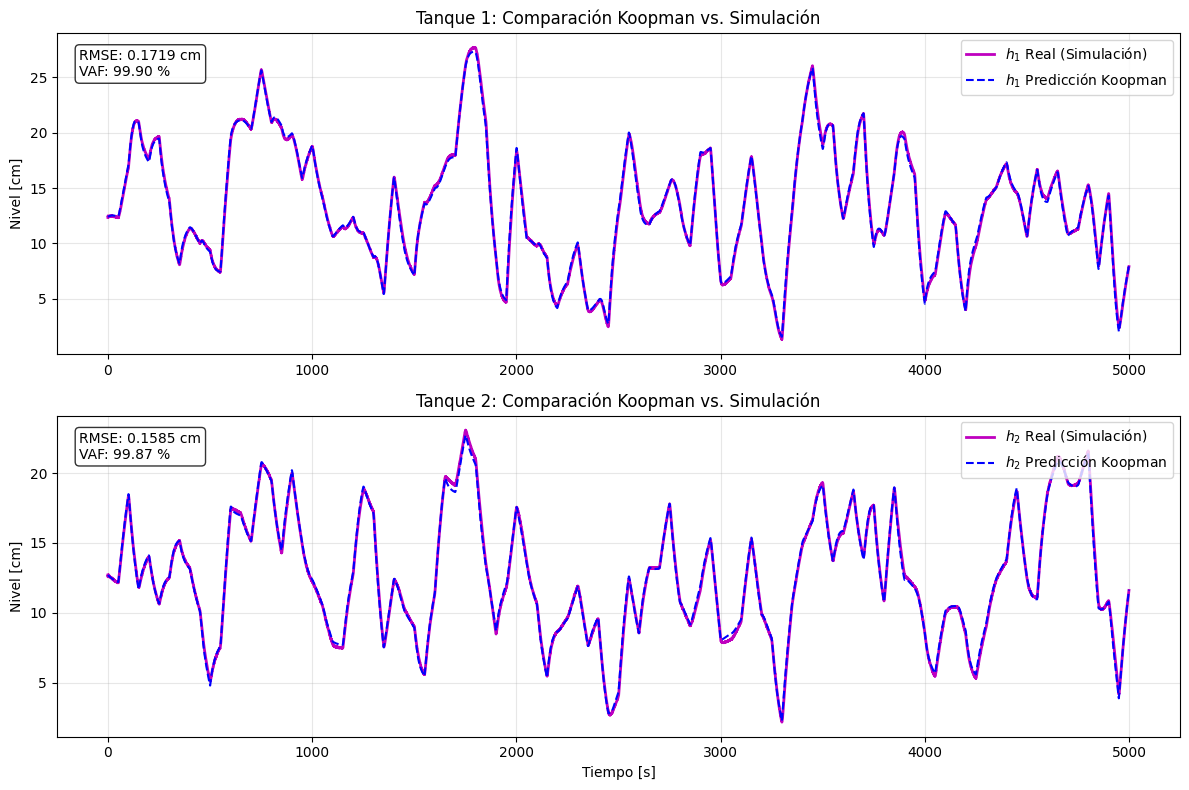

In [ ]:
# Visualización de resultados para tanques inferiores (h1 y h2)
plt.figure(figsize=(12, 8))

# Tanque 1: Comparativa y métricas
plt.subplot(2, 1, 1)
plt.plot(t_full, h1_full, 'm', linewidth=2, label='$h_1$ Real (Simulación)')
plt.plot(t_full, h_koopman[:, 0], 'b--', linewidth=1.5, label='$h_1$ Predicción Koopman')
plt.ylabel('Nivel [cm]')
plt.title('Tanque 1: Comparación Koopman vs. Simulación')
textstr1 = '\n'.join((f'RMSE: {rmse1:.4f} cm', f'VAF: {vaf1:.2f} %'))
plt.gca().text(0.02, 0.95, textstr1, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tanque 2: Comparativa y métricas
plt.subplot(2, 1, 2)
plt.plot(t_full, h2_full, 'm', linewidth=2, label='$h_2$ Real (Simulación)')
plt.plot(t_full, h_koopman[:, 1], 'b--', linewidth=1.5, label='$h_2$ Predicción Koopman')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.title('Tanque 2: Comparación Koopman vs. Simulación')
textstr2 = '\n'.join((f'RMSE: {rmse2:.4f} cm', f'VAF: {vaf2:.2f} %'))
plt.gca().text(0.02, 0.95, textstr2, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

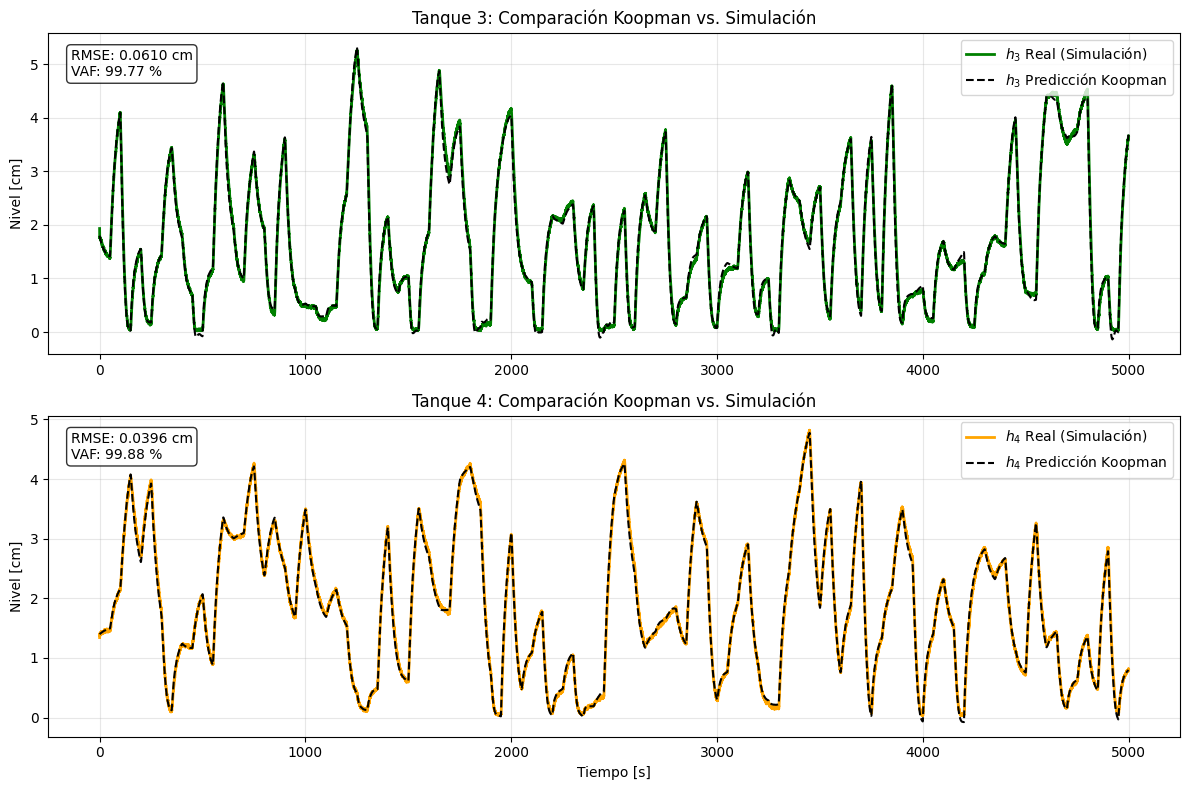

In [ ]:
# --- VISUALIZACIÓN IDENTIFICACIÓN: TANQUES SUPERIORES ---
plt.figure(figsize=(12, 8))

# Tanque 3: Comparativa y métricas
plt.subplot(2, 1, 1)
plt.plot(t_full, h3_full, 'g', linewidth=2, label='$h_3$ Real (Simulación)')
plt.plot(t_full, h_koopman[:, 2], 'k--', linewidth=1.5, label='$h_3$ Predicción Koopman')
plt.ylabel('Nivel [cm]')
plt.title('Tanque 3: Comparación Koopman vs. Simulación')
textstr3 = '\n'.join((f'RMSE: {rmse3:.4f} cm', f'VAF: {vaf3:.2f} %'))
plt.gca().text(0.02, 0.95, textstr3, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tanque 4: Comparativa y métricas
plt.subplot(2, 1, 2)
plt.plot(t_full, h4_full, 'orange', linewidth=2, label='$h_4$ Real (Simulación)')
plt.plot(t_full, h_koopman[:, 3], 'k--', linewidth=1.5, label='$h_4$ Predicción Koopman')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.title('Tanque 4: Comparación Koopman vs. Simulación')
textstr4 = '\n'.join((f'RMSE: {rmse4:.4f} cm', f'VAF: {vaf4:.2f} %'))
plt.gca().text(0.02, 0.95, textstr4, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

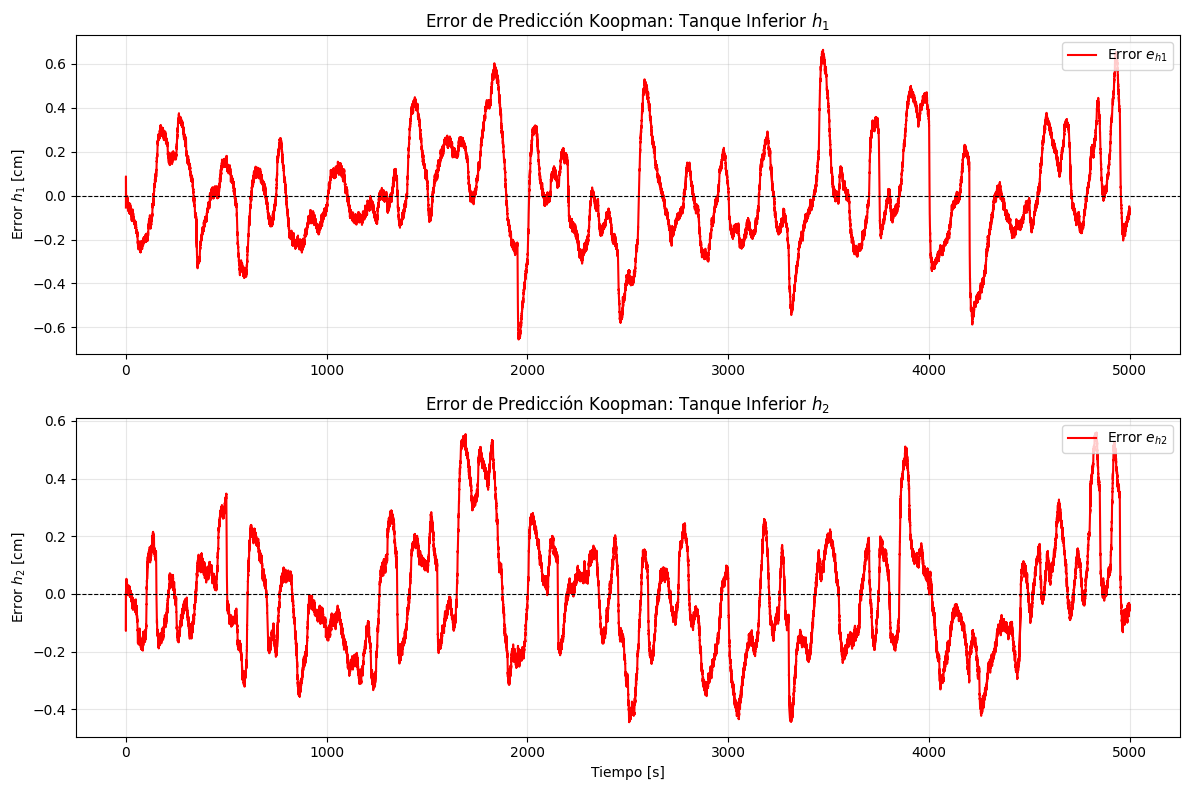

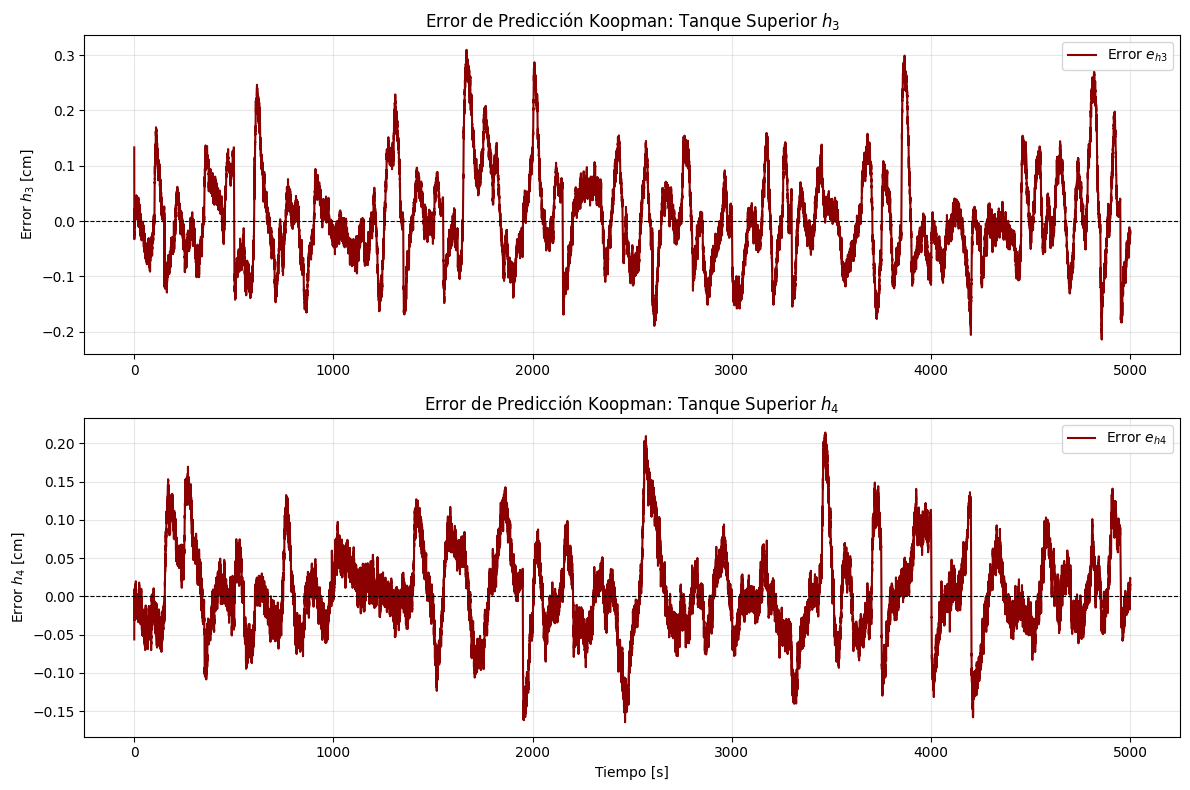

In [ ]:
# Cálculo del vector de error para los 4 tanques (Koopman vs Simulación)
error_h1_koopman = h1_full - h_koopman[:, 0]
error_h2_koopman = h2_full - h_koopman[:, 1]
error_h3_koopman = h3_full - h_koopman[:, 2]
error_h4_koopman = h4_full - h_koopman[:, 3]

# --- FIGURA: ERRORES EN TANQUES INFERIORES ---
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_full, error_h1_koopman, 'r', linewidth=1.5, label='Error $e_{h1}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel('Error $h_1$ [cm]')
plt.title('Error de Predicción Koopman: Tanque Inferior $h_1$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t_full, error_h2_koopman, 'r', linewidth=1.5, label='Error $e_{h2}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Error $h_2$ [cm]')
plt.title('Error de Predicción Koopman: Tanque Inferior $h_2$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- FIGURA: ERRORES EN TANQUES SUPERIORES ---
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_full, error_h3_koopman, 'darkred', linewidth=1.5, label='Error $e_{h3}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel('Error $h_3$ [cm]')
plt.title('Error de Predicción Koopman: Tanque Superior $h_3$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t_full, error_h4_koopman, 'darkred', linewidth=1.5, label='Error $e_{h4}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Error $h_4$ [cm]')
plt.title('Error de Predicción Koopman: Tanque Superior $h_4$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- EVALUACIÓN ESTADÍSTICA GLOBAL DEL MODELO KOOPMAN ---

# Concatenación de errores de los 4 tanques para métricas globales
error_full = np.concatenate((error_h1_koopman, error_h2_koopman, error_h3_koopman, error_h4_koopman))

# Cálculo de métricas estándar
MSE = np.mean(error_full**2)
RMSE = np.sqrt(MSE)
MAE = np.mean(np.abs(error_full))
SSE = np.sum(error_full**2)

# Cálculo del NRMSE (Error Cuadrático Medio Normalizado)
h_real_concat = h_out.flatten()
range_h = np.max(h_real_concat) - np.min(h_real_concat)

NRMSE = RMSE / range_h if range_h != 0 else 0.0

# Despliegue de resultados con formato científico
print("\n" + "="*30 + " MÉTRICAS GLOBALES DE IDENTIFICACIÓN KOOPMAN " + "="*30)
print(f"MSE (Error Cuadrático Medio)\t\t: {MSE:.8e} cm²")
print(f"RMSE (Raíz del Error Cuadrático)\t: {RMSE:.8e} cm")
print(f"MAE (Error Absoluto Medio)\t\t: {MAE:.8e} cm")
print(f"SSE (Suma del Error Cuadrático)\t\t: {SSE:.8e} cm²")
print(f"NRMSE (Error Normalizado)\t\t: {NRMSE:.8e} (Adimensional)")
print("-" * 105)


============================== MÉTRICAS GLOBALES DE IDENTIFICACIÓN KOOPMAN ==============================
MSE (Error Cuadrático Medio)		: 2.46205406e-02 cm²
RMSE (Raíz del Error Cuadrático)	: 1.56909339e-01 cm
MAE (Error Absoluto Medio)		: 1.10586018e-01 cm
SSE (Suma del Error Cuadrático)		: 9.84831473e+03 cm²
NRMSE (Error Normalizado)		: 5.67456689e-03 (Adimensional)
---------------------------------------------------------------------------------------------------------


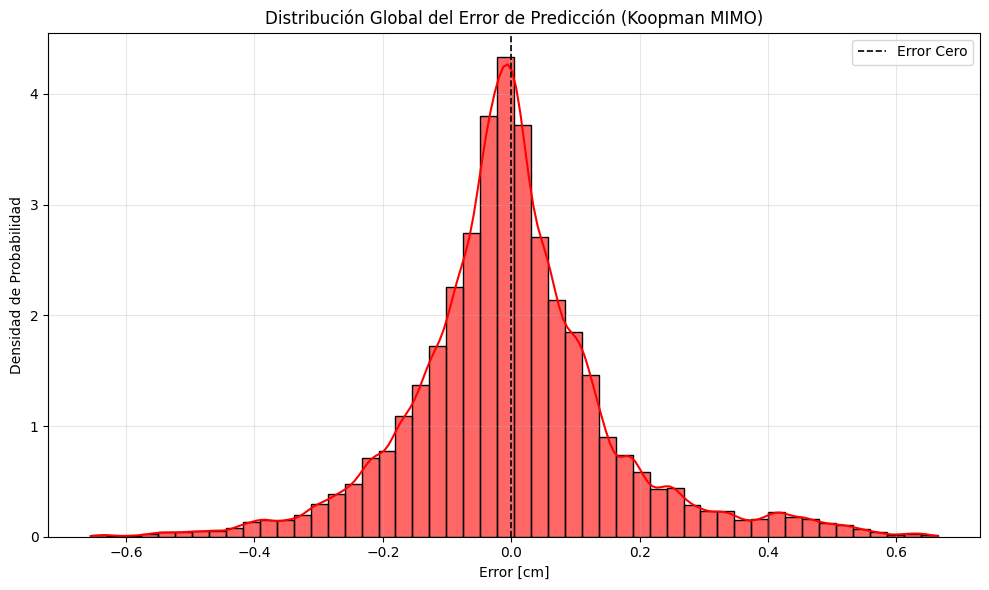

Desviación Estándar del Error : 0.156908 cm
Media del Error (Bias)        : -0.000576 cm


In [ ]:
# --- ANÁLISIS ESTADÍSTICO DE LA DISTRIBUCIÓN DEL ERROR ---
plt.figure(figsize=(10, 6))

# Visualización de la densidad del error global
sns.histplot(error_full, kde=True, color='red', bins=50, stat="density", alpha=0.6)

# Referencias estadísticas en la gráfica
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2, label='Error Cero')
plt.title('Distribución Global del Error de Predicción (Koopman MIMO)')
plt.xlabel('Error [cm]')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas de dispersión y sesgo
print(f"Desviación Estándar del Error : {np.std(error_full):.6f} cm")
print(f"Media del Error (Bias)        : {np.mean(error_full):.6f} cm")

In [ ]:
0# Configuración de horizonte y matrices de peso del controlador
N_horizon = 25
Nc = 1
dt = 0.2
Q = np.diag([500.0, 500.0, 0.0, 0.0])
R = np.diag([0.01, 0.01])
Rd = np.diag([1.0, 1.0])

# Dimensiones del sistema y horizonte de predicción
nx = A_k.shape[0]
nu = 2
N = N_horizon

# Definición de variables simbólicas para la optimización
U = ca.SX.sym('U', nu, Nc)
z0_sym = ca.SX.sym('z0', nx)
h_refs_sym = ca.SX.sym('h_refs', 4, N)
u_prev_sym = ca.SX.sym('u_prev', nu)

# Empaquetado de parámetros para el solver
P = ca.vertcat(z0_sym, ca.reshape(h_refs_sym, -1, 1), u_prev_sym)

# Inicialización de variables para el costo y restricciones de suavidad
costo = 0
g_slew = []

# Conversión de matrices de identificación a formato CasADi
Ak_ca = ca.DM(A_k)
B1k_ca = ca.DM(B1_k)
B2k_ca = ca.DM(B2_k)
Ck_ca = ca.DM(C_matrix)
Dk_ca = ca.DM(D_k)
Q_ca = ca.DM(Q[:4, :4])
R_ca = ca.DM(R)
Rd_ca = ca.DM(Rd)

In [ ]:
z_loop = z0_sym
for i in range(N):
    if i < Nc:
        u_k = U[:, i] # Variable de decisión libre
    else:
        u_k = U[:, Nc-1] # Se mantiene constante el último valor de control

    h_ref_k = h_refs_sym[:, i]

    # Predicción del siguiente estado usando el modelo bilineal de Koopman
    z_loop = Ak_ca @ z_loop + (B1k_ca @ z_loop)*u_k[0] + (B2k_ca @ z_loop)*u_k[1] + Dk_ca @ u_k

    # Cálculo del error de seguimiento en el espacio físico
    h_next = Ck_ca @ z_loop
    err = h_next - h_ref_k

    # Acumulación de costos: Seguimiento de referencia y esfuerzo de control
    costo += ca.mtimes([err.T, Q_ca, err])
    costo += ca.mtimes([u_k.T, R_ca, u_k])

    if i < Nc:
        u_prev_step = u_prev_sym if i == 0 else U[:, i-1]
        u_diff = u_k - u_prev_step
        costo += ca.mtimes([u_diff.T, Rd_ca, u_diff])
        g_slew.append(u_diff)

In [ ]:
# Vectorización de restricciones y variables de decisión
g_slew = ca.vertcat(*g_slew)
u_optim = ca.reshape(U, -1, 1)

# Estructura del problema de optimización para el solver OSQP
qp = {
    'x': u_optim,
    'f': costo,
    'g': g_slew,
    'p': P
}

# Configuración de opciones del solver para ejecución silenciosa
opts = {
    'osqp.verbose': False,
    'print_time': False,
    'error_on_fail': False
}

# Instanciación del solver QP de CasADi
solver = ca.qpsol('solver', 'osqp', qp, opts)

# Definición de límites físicos para los voltajes de las bombas
lbx = np.tile([V_min, V_min], Nc)
ubx = np.tile([V_max, V_max], Nc)

# Definición de límites para la variación máxima de voltaje (Slew Rate)
max_delta_v = 0.5
lbg = np.tile([-max_delta_v, -max_delta_v], Nc)
ubg = np.tile([max_delta_v, max_delta_v], Nc)

In [ ]:
# Generador de referencia de nivel constante
def ref_constante(t, valor=12.0):
    return valor

# Generador de referencia con perfil sinusoidal
def ref_sinusoidal(t, offset=12.0, amp=3.0, freq=0.01):
    return offset + amp * np.sin(2 * np.pi * freq * t)

# Generador de referencia tipo onda cuadrada
def ref_cuadrada(t, offset=9.0, amp=2.0, freq=0.005):
    return offset + amp * np.sign(np.sin(2 * np.pi * freq * t))

# Generador de referencia con dinámica de carga/descarga (Filtro RC)
def ref_filtro_rc(t, tau=10.0, t_cambio=50.0, v1=10.0, v2=14.0):
    ciclo = int(t / t_cambio)
    target = v2 if ciclo % 2 != 0 else v1
    t_relativo = t % t_cambio
    v_inicial = v2 if target == v1 else v1
    return target + (v_inicial - target) * np.exp(-t_relativo / tau)

# Generador de referencia por tramos (Step sequences)
def ref_escalon_secuencia(t, valores, periodo=400):
    indice = int(t / periodo) % len(valores)
    return valores[indice]

# Generador de referencia senoidal multivariable (MIMO)
def ref_sinusoidal_mimo(t, offset, amp_vector, periodo=400):
    # offset y amp_vector deben ser arreglos de numpy
    freq = 1.0 / periodo
    return offset + amp_vector * np.sin(2 * np.pi * freq * t)

# Asignación de trayectorias deseadas para los tanques de control
referencia_h1 = lambda t: ref_escalon_secuencia(t, [12, 15, 10, 14, 16])
referencia_h2 = lambda t: ref_escalon_secuencia(t, [16, 14, 10, 15, 12])
#referencia_h1 = lambda t: ref_sinusoidal(t)
#referencia_h2 = lambda t: ref_sinusoidal(t)

In [ ]:
# Parámetros de tiempo y discretización para la prueba de control
T_control = 1500
steps_control = int(T_control / dt)
t_test = np.linspace(0, T_control, steps_control)

# Preasignación de la matriz de referencias y niveles de ruido
h_ref_full = np.zeros((steps_control, 4))
std_sensor = 0.00
std_actuador = 0.00

# Construcción de la trayectoria de referencia completa para el experimento
for i in range(steps_control):
    t_actual = t_test[i]
    h_ref_full[i, 0] = referencia_h1(t_actual)
    h_ref_full[i, 1] = referencia_h2(t_actual)

In [ ]:
# Inicialización de registros y condiciones iniciales para el lazo cerrado
h_history = np.zeros((steps_control, 4))
u_history = np.zeros((steps_control, 2))
h_current = h0.copy()
u_prev_applied = np.array([3.0, 3.0])

print("Iniciando NMPC con CasADi (OSQP)... \n" + "-"*80)

for k in range(steps_control):
    # Lectura de sensores con ruido y transformación al espacio de Koopman
    h_medido = np.maximum(h_current + std_sensor * np.random.randn(4), 0.0)
    z_current = lift_func(h_medido.reshape(1, -1)).flatten()

    # Construcción de la ventana de referencias futuras para el horizonte N
    if k + N < steps_control:
        h_ref_horizon = h_ref_full[k : k + N].T
    else:
        pad = N - (steps_control - k)
        h_ref_horizon = np.hstack([h_ref_full[k:].T, np.tile(h_ref_full[-1:], (pad, 1)).T])

    # Preparación de parámetros de entrada para el optimizador
    p_val = ca.vertcat(z_current, h_ref_horizon.flatten(order='F'), u_prev_applied)

    # Resolución del problema de optimización cuadrática (QP)
    u_init = np.tile(u_prev_applied, Nc)
    sol = solver(x0=u_init, p=p_val, lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)
    u_init = sol['x']

    # Extracción de la primera acción de control óptima
    u_all_opt = np.array(sol['x']).reshape(Nc, 2)
    u_nmpc = u_all_opt[0, :]

    # Aplicación de control ruidoso a la planta real (modelo no lineal ODE)
    u_real = np.clip(u_nmpc + std_actuador * np.random.randn(2), V_min, V_max)
    sol_ode = solve_ivp(
        lambda t, y: nonlinear_ode_system_model(t, y, lambda _: u_real,
                     A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2),
        [0, dt], h_current, t_eval=[dt]
    )

    # Actualización de estados y almacenamiento de trayectoria
    h_current = sol_ode.y[:, -1]
    u_prev_applied = u_nmpc
    h_history[k] = h_current
    u_history[k] = u_nmpc

    # Monitor de progreso de la simulación
    if k % 100 == 0:
        print(f"{k:<6d} | {h_current[0]:5.2f}({h_ref_full[k,0]:5.2f}) | "
              f"{h_current[1]:5.2f}({h_ref_full[k,1]:5.2f}) | "
              f"{u_nmpc[0]:5.2f}V | {u_nmpc[1]:5.2f}V")

Iniciando NMPC con CasADi (OSQP)... 
--------------------------------------------------------------------------------
0      | 12.39(12.00) | 12.71(16.00) |  2.50V |  3.50V
100    | 12.00(12.00) | 15.91(16.00) |  2.04V |  5.26V
200    | 12.00(12.00) | 16.00(16.00) |  2.24V |  3.86V
300    | 12.00(12.00) | 16.00(16.00) |  2.34V |  3.87V
400    | 12.00(12.00) | 16.00(16.00) |  2.39V |  3.86V
500    | 12.00(12.00) | 16.00(16.00) |  2.43V |  3.84V
600    | 12.00(12.00) | 16.00(16.00) |  2.45V |  3.82V
700    | 12.00(12.00) | 16.00(16.00) |  2.46V |  3.81V
800    | 12.00(12.00) | 16.00(16.00) |  2.47V |  3.80V
900    | 12.00(12.00) | 16.00(16.00) |  2.48V |  3.80V
1000   | 12.00(12.00) | 16.00(16.00) |  2.49V |  3.79V
1100   | 12.00(12.00) | 16.00(16.00) |  2.49V |  3.79V
1200   | 12.00(12.00) | 16.00(16.00) |  2.49V |  3.79V
1300   | 12.00(12.00) | 16.00(16.00) |  2.49V |  3.79V
1400   | 12.00(12.00) | 16.00(16.00) |  2.50V |  3.79V
1500   | 12.00(12.00) | 16.00(16.00) |  2.50V |  3.79V
16

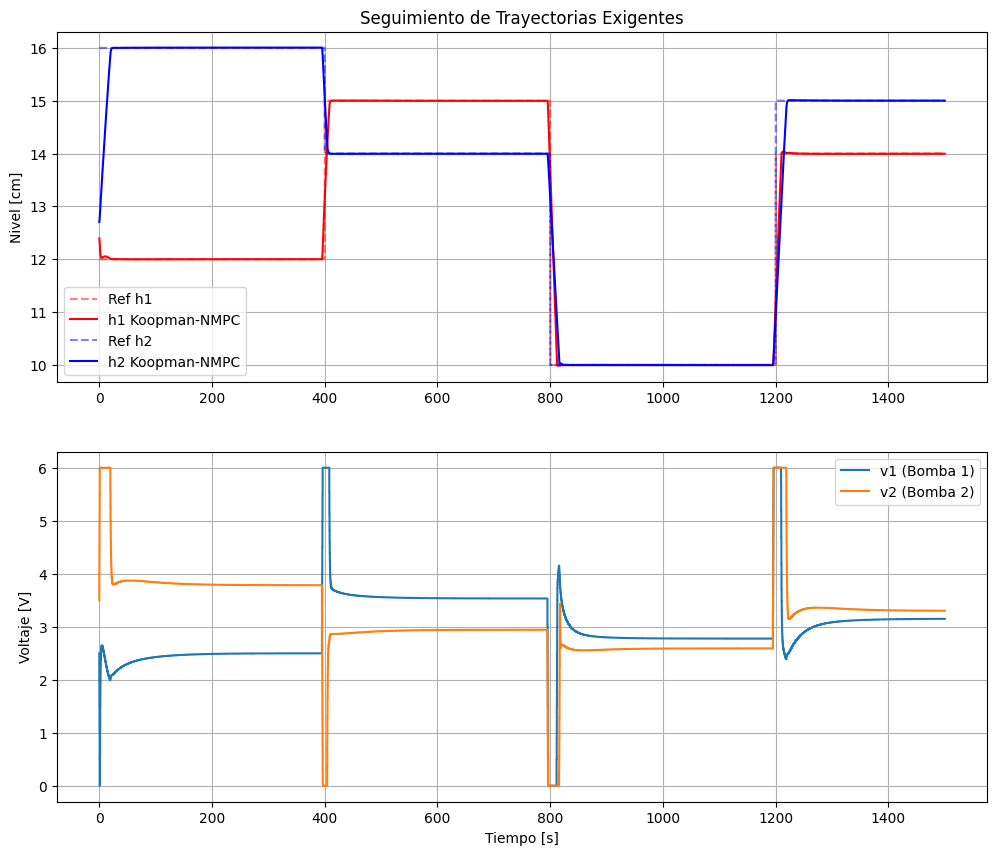

In [ ]:
# Gráficas finales del desempeño del seguimiento (Tracking)
plt.figure(figsize=(12, 10))

# Comparativa entre niveles reales alcanzados y referencias deseadas
plt.subplot(2, 1, 1)
plt.plot(t_test, h_ref_full[:, 0], 'r--', alpha=0.5, label='Ref h1')
plt.plot(t_test, h_history[:, 0], 'r', label='h1 Koopman-NMPC')
plt.plot(t_test, h_ref_full[:, 1], 'b--', alpha=0.5, label='Ref h2')
plt.plot(t_test, h_history[:, 1], 'b', label='h2 Koopman-NMPC')
plt.title('Seguimiento de Trayectorias Exigentes')
plt.ylabel('Nivel [cm]')
plt.legend()
plt.grid(True)

# Registro del esfuerzo de control (Voltaje aplicado a las bombas)
plt.subplot(2, 1, 2)
plt.step(t_test, u_history[:, 0], label='v1 (Bomba 1)')
plt.step(t_test, u_history[:, 1], label='v2 (Bomba 2)')
plt.ylabel('Voltaje [V]')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.grid(True)
plt.show()

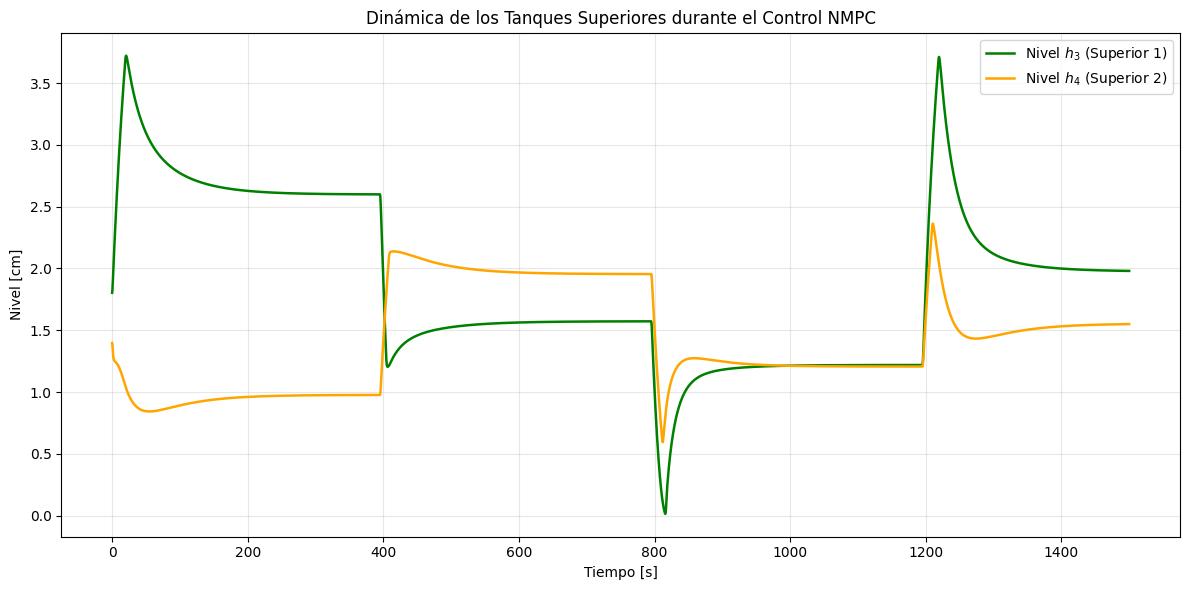

In [ ]:
# --- VISUALIZACIÓN DE DINÁMICA DE TANQUES SUPERIORES (SIN REFERENCIAS) ---
plt.figure(figsize=(12, 6))

# Trayectoria de h3 y h4
plt.plot(t_test, h_history[:, 2], 'g', linewidth=1.8, label='Nivel $h_3$ (Superior 1)')
plt.plot(t_test, h_history[:, 3], 'orange', linewidth=1.8, label='Nivel $h_4$ (Superior 2)')

plt.title('Dinámica de los Tanques Superiores durante el Control NMPC')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- CÁLCULO DE MÉTRICAS DE CONTROL: LOCALES Y GLOBALES ---

def calculate_control_metrics(real, ref):
    error = real - ref
    sse = np.sum(error**2)
    rmse = np.sqrt(np.mean(error**2))

    # NRMSE normalizado por el rango de la referencia
    range_ref = np.max(ref) - np.min(ref)
    nrmse = rmse / range_ref if range_ref != 0 else rmse

    return sse, rmse, nrmse

# 1. Métricas Individuales (Tanques h1 y h2)
sse1, rmse1, nrmse1 = calculate_control_metrics(h_history[:, 0], h_ref_full[:, 0])
sse2, rmse2, nrmse2 = calculate_control_metrics(h_history[:, 1], h_ref_full[:, 1])

# 2. Métricas Globales (Sistema MIMO Completo)
h_real_all = h_history[:, :2].flatten()
h_ref_all = h_ref_full[:, :2].flatten()

sse_global, rmse_global, nrmse_global = calculate_control_metrics(h_real_all, h_ref_all)

# --- REPORTE EXTENDIDO EN CONSOLA ---
print("\n" + "="*75)
print(f"{'MÉTRICA DE CONTROL':<25} | {'TANQUE 1':<12} | {'TANQUE 2':<12} | {'GLOBAL':<12}")
print("-" * 75)
print(f"{'SSE (Suma Error)':<25} | {sse1:12.2f} | {sse2:12.2f} | {sse_global:12.2f}")
print(f"{'RMSE (Precisión)':<25} | {rmse1:12.4f} | {rmse2:12.4f} | {rmse_global:12.4f}")
print(f"{'NRMSE (Normalizado)':<25} | {nrmse1:12.4f} | {nrmse2:12.4f} | {nrmse_global:12.4f}")
print("="*75 + "\n")


MÉTRICA DE CONTROL        | TANQUE 1     | TANQUE 2     | GLOBAL      
---------------------------------------------------------------------------
SSE (Suma Error)          |       490.58 |      1192.16 |      1682.74
RMSE (Precisión)          |       0.2558 |       0.3987 |       0.3349
NRMSE (Normalizado)       |       0.0512 |       0.0664 |       0.0558



Error medio h1: 1.0491 cm
Error medio h2: 1.2870 cm


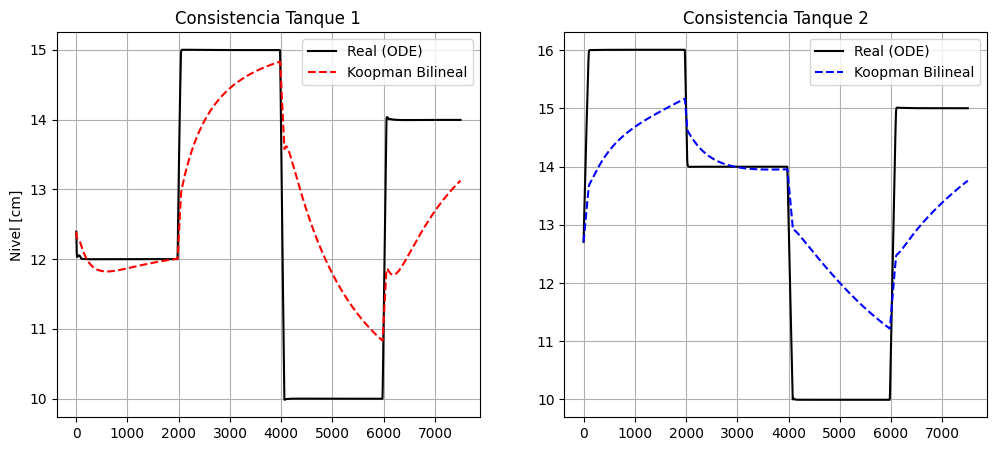

In [ ]:
# Verificación de consistencia: Modelo Koopman vs Sistema Real
n_val = steps_control
h_real_seg = h_history[:n_val]
u_seg = u_history[:n_val]

# Predicción en lazo abierto usando únicamente el modelo de Koopman identificado
h_koopman_val = np.zeros((n_val, 4))
z_val = lift_func(h_history[0].reshape(1, -1))[0]

for k in range(n_val):
    h_koopman_val[k] = C_matrix @ z_val

    if k < n_val - 1:
        u_k = u_seg[k]
        # Evolución temporal sin corrección por medición (Open Loop)
        z_val = A_k @ z_val + (B1_k @ z_val)*u_k[0] + (B2_k @ z_val)*u_k[1] + D_k @ u_k

# Evaluación cuantitativa del error de modelado (MAE)
mae_h1 = np.mean(np.abs(h_real_seg[:, 0] - h_koopman_val[:, 0]))
mae_h2 = np.mean(np.abs(h_real_seg[:, 1] - h_koopman_val[:, 1]))

print(f"Error medio h1: {mae_h1:.4f} cm")
print(f"Error medio h2: {mae_h2:.4f} cm")

# Gráficas de validación para comparar la fidelidad del modelo bilineal
plt.figure(figsize=(12, 5))

# Comparativa de trayectorias para el Tanque 1
plt.subplot(1, 2, 1)
plt.plot(h_real_seg[:, 0], 'k', label='Real (ODE)')
plt.plot(h_koopman_val[:, 0], 'r--', label='Koopman Bilineal')
plt.title('Consistencia Tanque 1')
plt.ylabel('Nivel [cm]')
plt.legend()
plt.grid(True)

# Comparativa de trayectorias para el Tanque 2
plt.subplot(1, 2, 2)
plt.plot(h_real_seg[:, 1], 'k', label='Real (ODE)')
plt.plot(h_koopman_val[:, 1], 'b--', label='Koopman Bilineal')
plt.title('Consistencia Tanque 2')
plt.legend()
plt.grid(True)
plt.show()

Error medio h3: 0.1589 cm
Error medio h4: 0.1425 cm


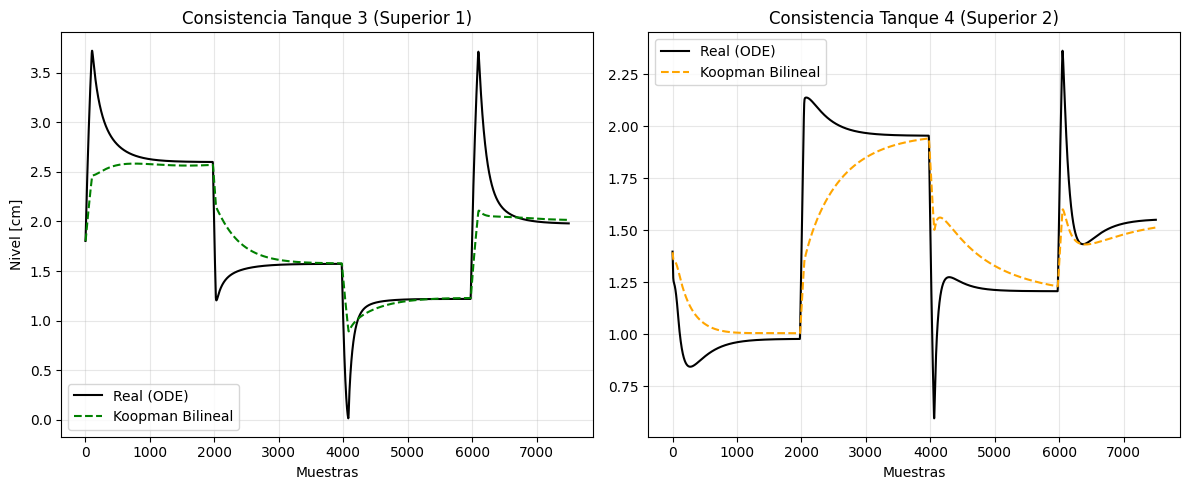

In [ ]:
# --- VERIFICACIÓN DE CONSISTENCIA: TANQUES SUPERIORES (h3 y h4) ---
# Evaluación cuantitativa del error de modelado para tanques superiores (MAE)
mae_h3 = np.mean(np.abs(h_real_seg[:, 2] - h_koopman_val[:, 2]))
mae_h4 = np.mean(np.abs(h_real_seg[:, 3] - h_koopman_val[:, 3]))

print(f"Error medio h3: {mae_h3:.4f} cm")
print(f"Error medio h4: {mae_h4:.4f} cm")

# Gráficas de validación para comparar la fidelidad del modelo en los niveles superiores
plt.figure(figsize=(12, 5))

# Comparativa de trayectorias para el Tanque 3
plt.subplot(1, 2, 1)
plt.plot(h_real_seg[:, 2], 'k', label='Real (ODE)')
plt.plot(h_koopman_val[:, 2], 'g--', label='Koopman Bilineal')
plt.title('Consistencia Tanque 3 (Superior 1)')
plt.ylabel('Nivel [cm]')
plt.xlabel('Muestras')
plt.legend()
plt.grid(True, alpha=0.3)

# Comparativa de trayectorias para el Tanque 4
plt.subplot(1, 2, 2)
plt.plot(h_real_seg[:, 3], 'k', label='Real (ODE)')
plt.plot(h_koopman_val[:, 3], 'orange', linestyle='--', label='Koopman Bilineal')
plt.title('Consistencia Tanque 4 (Superior 2)')
plt.xlabel('Muestras')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Interpolación de voltajes del NMPC para integración continua
u_nmpc_fun = interp1d(t_test, u_history, axis=0, kind='linear', fill_value='extrapolate')

# Wrapper del modelo real alimentado por la secuencia de control calculada
ode_validation_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_nmpc_fun,
    A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2
)

# Simulación de la planta física real en lazo abierto para validación cruzada
sol_validation = solve_ivp(
    fun=ode_validation_wrapper,
    t_span=[t_test[0], t_test[-1]],
    y0=h0,
    method='RK45',
    t_eval=t_test,
    rtol=1e-7,
    atol=1e-9
)
h_real_validation = sol_validation.y.T

# Visualización comparativa: NMPC vs Planta Real vs Referencia
plt.figure(figsize=(12, 12))

# Análisis de fidelidad para el Tanque 1
plt.subplot(2, 1, 1)
plt.plot(t_test, h_ref_full[:, 0], 'k:', alpha=0.3, label='Referencia')
plt.plot(t_test, h_history[:, 0], 'r', linewidth=2, label='Trayectoria NMPC (Lazo Cerrado)')
plt.plot(t_test, h_real_validation[:, 0], 'b--', linewidth=1.5, label='Sistema Real (Lazo Abierto)')
plt.title('Validación de Fidelidad: Tanque 1')
plt.ylabel('Nivel [cm]')
plt.legend()
plt.grid(True, alpha=0.3)

# Análisis de fidelidad para el Tanque 2
plt.subplot(2, 1, 2)
plt.plot(t_test, h_ref_full[:, 1], 'k:', alpha=0.3, label='Referencia')
plt.plot(t_test, h_history[:, 1], 'm', linewidth=2, label='Trayectoria NMPC (Lazo Cerrado)')
plt.plot(t_test, h_real_validation[:, 1], 'c--', linewidth=1.5, label='Sistema Real (Lazo Abierto)')
plt.title('Validación de Fidelidad: Tanque 2')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cuantificación de la discrepancia final entre el modelo y la planta
discrepancia_h1 = np.mean(np.abs(h_history[:, 0] - h_real_validation[:, 0]))
print(f"Discrepancia promedio en h1: {discrepancia_h1:.5f} cm")

In [ ]:
# --- VALIDACIÓN DE FIDELIDAD: TANQUES SUPERIORES (h3 y h4) ---

plt.figure(figsize=(12, 10))

# Análisis de fidelidad para el Tanque 3 (Superior 1)
plt.subplot(2, 1, 1)
# Trayectoria obtenida durante la ejecución del NMPC (basada en el modelo Koopman)
plt.plot(t_test, h_history[:, 2], 'g', linewidth=2, label='Trayectoria NMPC (Modelo Koopman)')
# Trayectoria recalculada usando la ODE no lineal real con los mismos voltajes
plt.plot(t_test, h_real_validation[:, 2], 'k--', linewidth=1.5, alpha=0.8, label='Sistema Real (Planta ODE)')
plt.title('Validación de Fidelidad: Tanque Superior 3')
plt.ylabel('Nivel [cm]')
plt.legend()
plt.grid(True, alpha=0.3)

# Análisis de fidelidad para el Tanque 4 (Superior 2)
plt.subplot(2, 1, 2)
plt.plot(t_test, h_history[:, 3], 'orange', linewidth=2, label='Trayectoria NMPC (Modelo Koopman)')
plt.plot(t_test, h_real_validation[:, 3], 'k--', linewidth=1.5, alpha=0.8, label='Sistema Real (Planta ODE)')
plt.title('Validación de Fidelidad: Tanque Superior 4')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cálculo de la discrepancia (Error de predicción en lazo cerrado)
discrepancia_h3 = np.mean(np.abs(h_history[:, 2] - h_real_validation[:, 2]))
discrepancia_h4 = np.mean(np.abs(h_history[:, 3] - h_real_validation[:, 3]))

print(f"Discrepancia promedio en h3: {discrepancia_h3:.5f} cm")
print(f"Discrepancia promedio en h4: {discrepancia_h4:.5f} cm")